<a href="https://colab.research.google.com/github/ismael-almazan/Ingenier-a-de-datos-avanzada/blob/main/data_profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1>MAESTRIA EN INTELIGENCIA ARTIFICIAL Y ANALITICA DE DATOS <h1>**

<h2>MATERIA: INGENIERIA DE DATOS AVANZADA<h2>

<h3>DOCENTE: VICENTE GARCIA JIMENEZ <h3>

**<h3>ALUMNO: ISMAEL ALMAZAN LUNA<h3>**

FECHA: 02/05/2026


# Actividad: Data Profiling con PySpark
**Descripción:**

En esta actividad realizarás un análisis exploratorio y de calidad de datos (data profiling) utilizando PySpark sobre el dataset proporcionado. El objetivo es comprender la estructura, distribución y posibles problemas en los datos desde un enfoque escalable.

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
!pip install ydata-profiling[pyspark]
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

/tmp/ipykernel_4124/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## Carga del Dataframe con PySpark

In [3]:
# Crear la SparkSesion
spark = SparkSession.builder \
.appName("NYC Taxi Profiling") \
.getOrCreate()

!wget -O taxi.csv "https://www.dropbox.com/scl/fi/ya6wwi1ouvu7b5ng00zu3/yellow_tripdata_2016-03.csv?rlkey=49gbpo35mmh7p2codjw4kcfd3&dl=1"

df = spark.read.csv("taxi.csv", header=True, inferSchema=True)

# Compobar que se haya cargado el df
df.show()

--2026-05-04 00:56:42--  https://www.dropbox.com/scl/fi/ya6wwi1ouvu7b5ng00zu3/yellow_tripdata_2016-03.csv?rlkey=49gbpo35mmh7p2codjw4kcfd3&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc380f7c6ba267514ec7fae66b00.dl.dropboxusercontent.com/cd/0/inline/C_wa8EUV98IRHIiAudp3dv1GDQmKEFIUsuUC_ASrhGMSii1t_xzkW3bOWVhSDzfyCK0-X2BF8yD_nK3pvTNXquwcD7hfKI0BtpHGPEmb2LdyJ_3mvsW0s6w8k6rbfbGFTJM/file?dl=1# [following]
--2026-05-04 00:56:42--  https://uc380f7c6ba267514ec7fae66b00.dl.dropboxusercontent.com/cd/0/inline/C_wa8EUV98IRHIiAudp3dv1GDQmKEFIUsuUC_ASrhGMSii1t_xzkW3bOWVhSDzfyCK0-X2BF8yD_nK3pvTNXquwcD7hfKI0BtpHGPEmb2LdyJ_3mvsW0s6w8k6rbfbGFTJM/file?dl=1
Resolving uc380f7c6ba267514ec7fae66b00.dl.dropboxusercontent.com (uc380f7c6ba267514ec7fae66b00.dl.dropboxusercontent.com)... 162.125.83.15, 2620:100:6033:15:

## Data **Profiling**

In [4]:
#Estructura del dataset (schema, número de filas y columnas)
print("Dimensiones del DataFrame:")
print(f"Filas: {df.count()}")
print(f"Columnas: {len(df.columns)}")

Dimensiones del DataFrame:
Filas: 12210952
Columnas: 19


In [ ]:
#Estadísticos descriptivos (describe o summary)
print("Estadísticos descriptivos:")
df.summary().show()

+-------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+---------------------+-----------------+
|summary|          VendorID|   passenger_count|     trip_distance|   pickup_longitude|   pickup_latitude|        RatecodeID|store_and_fwd_flag|  dropoff_longitude|  dropoff_latitude|      payment_type|       fare_amount|              extra|            mta_tax|        tip_amount|       tolls_amount|improvement_surcharge|     total_amount|
+-------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+---------------------

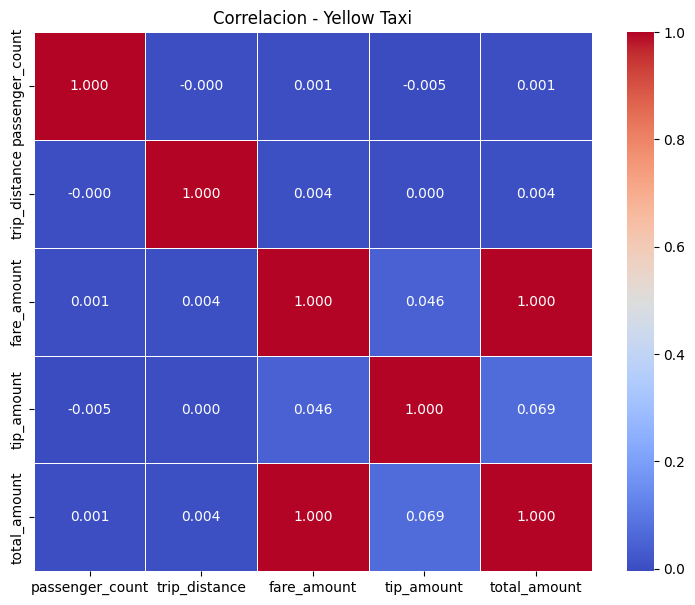

In [10]:
# Columnas numericas
cols = ["passenger_count", "trip_distance", "fare_amount", "tip_amount", "total_amount"]

matriz_datos = []

for c1 in cols:
    fila = [df.stat.corr(c1, c2) for c2 in cols]
    matriz_datos.append(fila)

# Para graficar
df_corr = pd.DataFrame(matriz_datos, index=cols, columns=cols)

# Heatmap
plt.figure(figsize=(9,7))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Correlacion - Yellow Taxi")
plt.show()

In [14]:
# Valores Nulos y Faltantes
from pyspark.sql.functions import col, count, when, lit

nulos_df = df.select([
    (count(when(col(c).isNull(), c)) / df.count() * 100).alias(c)
    for c in df.columns
])
print("Porcentaje de valores nulos por columna:")
nulos_df.show()

Porcentaje de valores nulos por columna:
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|pickup_longitude|pickup_latitude|RatecodeID|store_and_fwd_flag|dropoff_longitude|dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------------+---------------+----------+------------------+-----------------+----------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|     0.0|                 0.0|                  0.0|            0.0|          0.0|             0.0|            0.0|   

# ydata-profiling

In [15]:
!pip install ydata-profiling[pyspark]

In [17]:
# Columnas
cols_interes = [
    "passenger_count", "trip_distance", "fare_amount",
    "tip_amount", "total_amount", "payment_type", "RatecodeID"
]


df_profiling = df.select(cols_interes).sample(fraction=0.01, seed=42)

# Generar el reporte
reporte = ProfileReport(
    df_profiling,
    title="Profiling Yellow Taxi - Marzo 2016",
    explorative=True,
    interactions=None
)

# Mostra
reporte.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]